In [ ]:
import sys, os
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# Fundamental Features: Weather Demand & Storage Surprises

**Strategy context:**  
We predict intra-curve dislocations in the Henry Hub forward curve. Two forces drive demand shocks that create temporary mispricings:
1. **Weather** — unexpected heating/cooling demand that the curve hasn't fully priced.
2. **Storage** — EIA weekly release surprise vs. market consensus.

**Reference:** Chen, Hartley & Lan (2023), *Temperature, Storage, and Natural Gas Futures Prices* — adapted from hourly to daily data.

**Anti-lookahead rule:** All features at date $t$ use only data observable at the close of $t$.
The ML target is $y_{z,i,t} = \sum_{k=1}^{5} \varepsilon_{i,t+k} / (\sqrt{5}\,\sigma_\varepsilon)$, entered at $t+1$.

---

| Section | Content |
|---|---|
| §1 | Base features |
| §2 | Rolling aggregates |
| §3 | Historical climate normals |
| §4 | Expected/unexpected weather (walk-forward ARMAX) |
| §5 | 5-day-ahead forecast weather shocks |
| §6 | EIA storage announcements |
| §7 | Storage-window weather |
| §8 | Expected/unexpected ΔStorage |
| §9 | Daily panel merge + summary |
| §10 | Save |

In [1]:
import sys
sys.path.insert(0, '/Users/dnn/Oxford/OAF')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 40)

DATA_DIR     = Path('/Users/dnn/Oxford/OAF/data')
WEATHER_PATH = DATA_DIR / 'HDD:CDD' / 'weather_CONUS.csv'
STORAGE_PATH = DATA_DIR / 'EIA'     / 'US_storage_daily_ffill.csv'
OUT_DIR      = DATA_DIR / 'features'
OUT_DIR.mkdir(exist_ok=True)

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
df_weather = (
    pd.read_csv(WEATHER_PATH, parse_dates=['date'])
    .set_index('date')[['HDD', 'CDD']]
    .sort_index()
)

df_storage = (
    pd.read_csv(STORAGE_PATH, parse_dates=['date'], index_col='date')
    .sort_index()
)

print('Weather:', df_weather.shape, '|', df_weather.index[0].date(), '→', df_weather.index[-1].date())
print('Storage:', df_storage.shape, '|', df_storage.index[0].date(), '→', df_storage.index[-1].date())

# Merge onto common calendar index
df = (
    df_weather
    .join(df_storage.rename(columns={'gas_storage_bcf': 'Storage'}), how='outer')
    .sort_index()
)
df.index = pd.to_datetime(df.index)
df.index.name = 'date'
print('\nJoined panel:', df.shape)
df

Weather: (5906, 2) | 2010-01-01 → 2026-03-03
Storage: (5895, 1) | 2010-01-01 → 2026-02-20

Joined panel: (5906, 3)


,HDD,CDD,Storage
date,,,
2010-01-01,30,0,3117.000
2010-01-02,35,0,3117.000
2010-01-03,38,0,3117.000
2010-01-04,37,0,3117.000
2010-01-05,36,0,3117.000
...,...,...,...
2026-02-27,16,1,NaN
2026-02-28,16,1,NaN
2026-03-01,19,1,NaN


In [3]:
df.isna().sum()

HDD         0
CDD         0
Storage    11
dtype: int64

## §1 — Base Weather Features

**Level and quadratic terms** capture nonlinear demand: at extreme cold/heat, marginal demand rises faster.

$$HDD_t^2, \quad CDD_t^2$$

**Daily increments** capture momentum in the weather shock:

$$\Delta HDD_t = HDD_t - HDD_{t-1}$$

$$HDD_{\text{inc},t} = \max(\Delta HDD_t,\, 0) \qquad \text{(cold intensifying)}$$
$$HDD_{\text{dec},t} = \max(-\Delta HDD_t,\, 0) \qquad \text{(cold abating)}$$

**Timing note:** $HDD_t$ and $CDD_t$ are population-weighted degree days for CONUS, released daily — treated as known at close of $t$.

In [4]:
from features.fundamental import prepare_base

df = prepare_base(df, lag_weather=False)

base_cols = ['HDD', 'CDD', 'HDD2', 'CDD2',
             'HDD_inc', 'HDD_dec', 'CDD_inc', 'CDD_dec']
print(f'Added {len(base_cols)} base features')
df[base_cols].describe().round(2)

Added 8 base features


,HDD,CDD,HDD2,CDD2,HDD_inc,HDD_dec,CDD_inc,CDD_dec
count,5906.000,5906.000,5906.000,5906.000,5905.000,5905.000,5905.000,5905.000
mean,11.360,3.770,244.990,33.500,0.620,0.630,0.220,0.210
std,10.770,4.390,328.700,52.920,1.290,1.170,0.470,0.510
min,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000
25%,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
50%,9.000,1.000,81.000,1.000,0.000,0.000,0.000,0.000
75%,20.000,7.000,400.000,49.000,1.000,1.000,0.000,0.000
max,45.000,17.000,2025.000,289.000,9.000,9.000,3.000,5.000


In [5]:
df

,HDD,CDD,Storage,HDD2,CDD2,HDD_inc,HDD_dec,CDD_inc,CDD_dec
date,,,,,,,,,
2010-01-01,30,0,3117.000,900,0,NaN,NaN,NaN,NaN
2010-01-02,35,0,3117.000,1225,0,5.000,0.000,0.000,-0.000
2010-01-03,38,0,3117.000,1444,0,3.000,0.000,0.000,-0.000
2010-01-04,37,0,3117.000,1369,0,0.000,1.000,0.000,-0.000
2010-01-05,36,0,3117.000,1296,0,0.000,1.000,0.000,-0.000
...,...,...,...,...,...,...,...,...,...
2026-02-27,16,1,NaN,256,1,0.000,3.000,1.000,0.000
2026-02-28,16,1,NaN,256,1,0.000,-0.000,0.000,-0.000
2026-03-01,19,1,NaN,361,1,3.000,0.000,0.000,-0.000


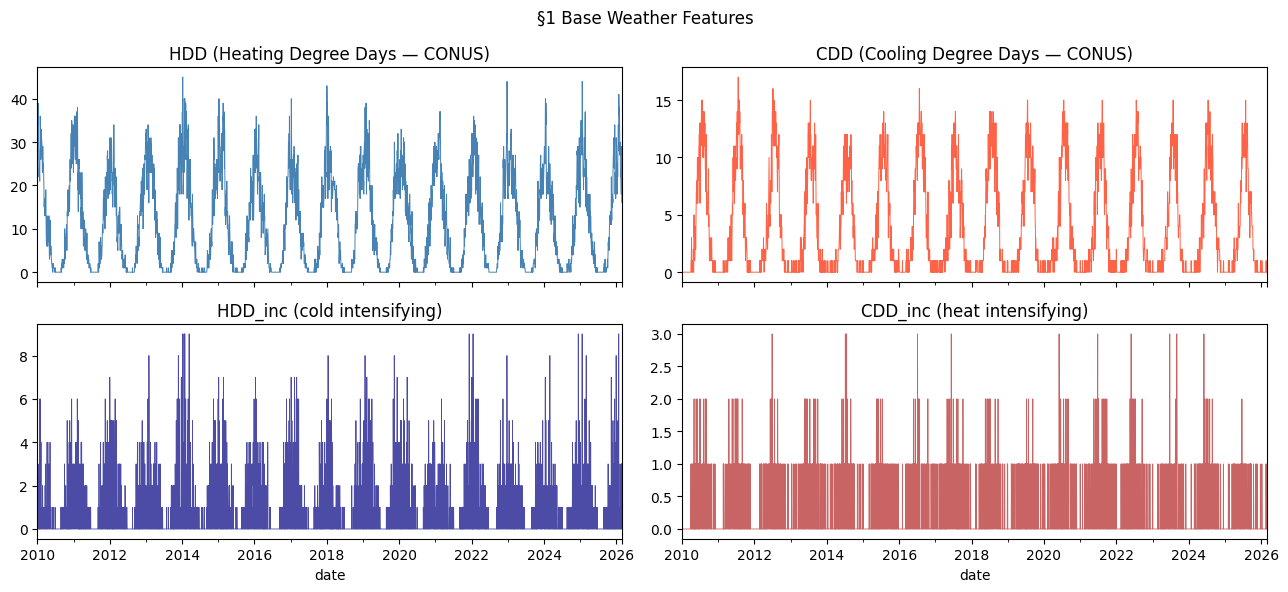

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)

df['HDD'].plot(ax=axes[0,0], color='steelblue', lw=0.7)
axes[0,0].set_title('HDD (Heating Degree Days — CONUS)')

df['CDD'].plot(ax=axes[0,1], color='tomato', lw=0.7)
axes[0,1].set_title('CDD (Cooling Degree Days — CONUS)')

df['HDD_inc'].plot(ax=axes[1,0], color='navy', lw=0.6, alpha=0.7)
axes[1,0].set_title('HDD_inc (cold intensifying)')

df['CDD_inc'].plot(ax=axes[1,1], color='firebrick', lw=0.6, alpha=0.7)
axes[1,1].set_title('CDD_inc (heat intensifying)')

plt.suptitle('§1 Base Weather Features', fontsize=12)
plt.tight_layout()
plt.show()

## §2 — Rolling Weather Aggregates

Short-window sums/means capture the accumulated demand pressure heading into the signal date.

$$HDD\text{-sum}_{w,t} = \sum_{k=0}^{w-1} HDD_{t-k}$$

$$HDD\text{-var}_{w,t} = \operatorname{Var}\bigl(HDD_{t-w+1}, \ldots, HDD_t\bigr)$$

Windows: $w \in \{3, 5, 7, 10, 20\}$.  
All computed backward from $t$ inclusive — no lookahead.

Added 10 rolling features


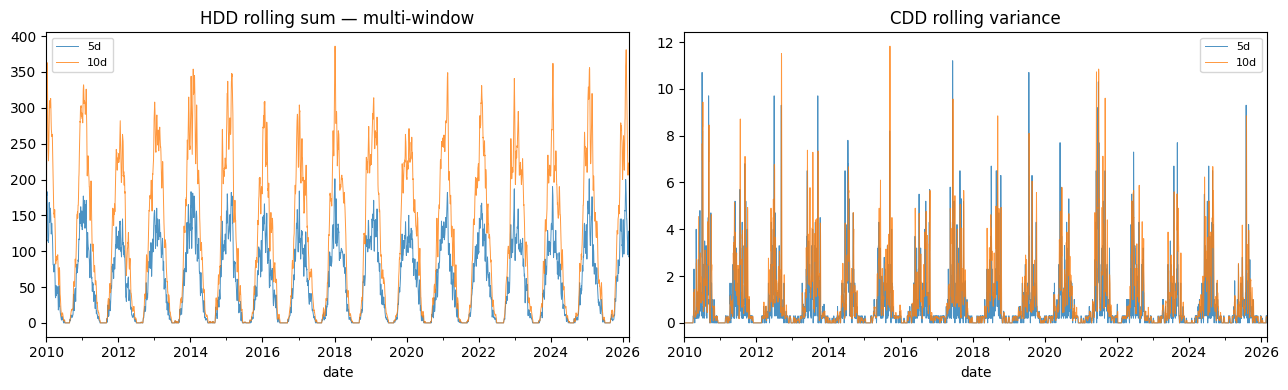

In [7]:
from features.fundamental import add_weather_rolling_features

df = add_weather_rolling_features(df)

roll_cols = [c for c in df.columns if any(c.endswith(f'_{w}d') for w in [5, 10])]
print(f'Added {len(roll_cols)} rolling features')

# HDD accumulated demand by window
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for w in [5, 10]:
    df[f'HDD_sum_{w}d'].plot(ax=axes[0], lw=0.7, label=f'{w}d', alpha=0.8)
axes[0].legend(fontsize=8)
axes[0].set_title('HDD rolling sum — multi-window')

for w in [5, 10]:
    df[f'CDD_var_{w}d'].plot(ax=axes[1], lw=0.7, label=f'{w}d', alpha=0.8)
axes[1].legend(fontsize=8)
axes[1].set_title('CDD rolling variance')

plt.tight_layout()
plt.show()

In [8]:
df

,HDD,CDD,Storage,HDD2,CDD2,HDD_inc,HDD_dec,CDD_inc,CDD_dec,HDD_sum_5d,HDD_mean_5d,HDD_var_5d,HDD_sum_10d,HDD_var_10d,CDD_sum_5d,CDD_mean_5d,CDD_var_5d,CDD_sum_10d,CDD_var_10d
date,,,,,,,,,,,,,,,,,,,
2010-01-01,30,0,3117.000,900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02,35,0,3117.000,1225,0,5.000,0.000,0.000,-0.000,NaN,NaN,12.500,NaN,NaN,NaN,NaN,0.000,NaN,NaN
2010-01-03,38,0,3117.000,1444,0,3.000,0.000,0.000,-0.000,103.000,34.333,16.333,NaN,NaN,0.000,0.000,0.000,NaN,NaN
2010-01-04,37,0,3117.000,1369,0,0.000,1.000,0.000,-0.000,140.000,35.000,12.667,NaN,NaN,0.000,0.000,0.000,NaN,NaN
2010-01-05,36,0,3117.000,1296,0,0.000,1.000,0.000,-0.000,176.000,35.200,9.700,176.000,9.700,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27,16,1,NaN,256,1,0.000,3.000,1.000,0.000,114.000,22.800,29.200,220.000,18.889,1.000,0.200,0.200,4.000,0.267
2026-02-28,16,1,NaN,256,1,0.000,-0.000,0.000,-0.000,101.000,20.200,22.700,218.000,21.067,2.000,0.400,0.300,5.000,0.278
2026-03-01,19,1,NaN,361,1,3.000,0.000,0.000,-0.000,93.000,18.600,8.300,219.000,20.322,3.000,0.600,0.300,5.000,0.278


## §3 — Historical Climate Normals

The **normal** at date $t$ is the historical average for the same day of year, computed without any future data:

$$\bar{X}_{\text{normal},t} = \frac{1}{|\mathcal{S}_t|} \sum_{s \in \mathcal{S}_t} X_s$$

where the eligible set is:
$$\mathcal{S}_t = \Bigl\{ s \;:\; s < t,\quad \text{year}(s) \in [\text{year}(t)-4,\, \text{year}(t)-1],\quad \bigl|\text{doy}(s) - \text{doy}(t)\bigr|_{\bmod 365} \leq 3 \Bigr\}$$

With `lookback_years=4` and `day_window=3`, this uses ≈ 4 × 7 = 28 past observations per date.

**Anti-lookahead:** `year(s) ≤ year(t) − 1` ensures $s < t$ for all calendar dates.

**Anomaly:** $X_{\text{anom},t} = X_t - \bar{X}_{\text{normal},t}$ — today's weather vs. climatology.

In [9]:
from features.fundamental import add_historical_normals

normal_cols = ['HDD', 'CDD', 'HDD2', 'CDD2']
print('Computing historical normals (expanding, ~30s)...')
df = add_historical_normals(df, normal_cols, lookback_years=4, day_window=3, min_obs=10)

norm_output = [c for c in df.columns if 'normal' in c or 'anom' in c]
print(f'Added {len(norm_output)} normal/anomaly features')
df[['HDD', 'HDD_normal_4y_pm3d', 'HDD_anom_normal',
    'CDD', 'CDD_normal_4y_pm3d', 'CDD_anom_normal']].describe().round(2)

Computing historical normals (expanding, ~30s)...
Added 8 normal/anomaly features


,HDD,HDD_normal_4y_pm3d,HDD_anom_normal,CDD,CDD_normal_4y_pm3d,CDD_anom_normal
count,5906.000,5176.000,5176.000,5906.000,5176.000,5176.000
mean,11.360,11.410,-0.110,3.770,3.800,-0.040
std,10.770,10.240,3.910,4.390,4.260,1.380
min,0.000,0.000,-16.430,0.000,0.000,-7.540
25%,1.000,1.100,-1.820,0.000,0.290,-0.540
50%,9.000,9.140,-0.070,1.000,1.360,-0.070
75%,20.000,21.460,1.290,7.000,7.480,0.640
max,45.000,34.640,21.710,17.000,14.500,5.950


In [10]:
df[norm_output]

,HDD_normal_4y_pm3d,HDD_anom_normal,CDD_normal_4y_pm3d,CDD_anom_normal,HDD2_normal_4y_pm3d,HDD2_anom_normal,CDD2_normal_4y_pm3d,CDD2_anom_normal
date,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-02-27,20.857,-4.857,0.321,0.679,457.357,-201.357,0.321,0.679
2026-02-28,20.321,-4.321,0.286,0.714,432.250,-176.250,0.286,0.714
2026-03-01,19.643,-0.643,0.286,0.714,401.357,-40.357,0.286,0.714


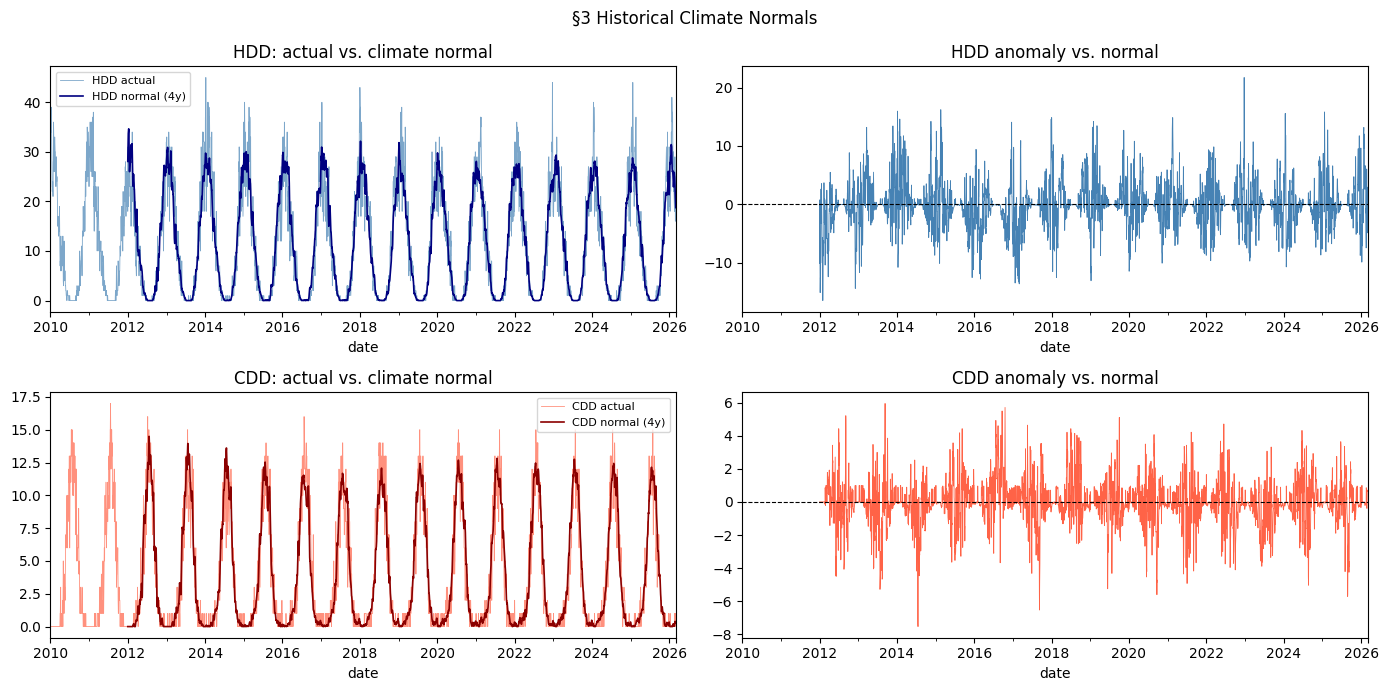

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# HDD: actual vs normal
ax = axes[0, 0]
df['HDD'].plot(ax=ax, lw=0.6, color='steelblue', alpha=0.7, label='HDD actual')
df['HDD_normal_4y_pm3d'].plot(ax=ax, lw=1.2, color='navy', label='HDD normal (4y)')
ax.set_title('HDD: actual vs. climate normal')
ax.legend(fontsize=8)

# HDD anomaly
ax = axes[0, 1]
df['HDD_anom_normal'].plot(ax=ax, lw=0.6, color='steelblue')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('HDD anomaly vs. normal')

# CDD: actual vs normal
ax = axes[1, 0]
df['CDD'].plot(ax=ax, lw=0.6, color='tomato', alpha=0.7, label='CDD actual')
df['CDD_normal_4y_pm3d'].plot(ax=ax, lw=1.2, color='darkred', label='CDD normal (4y)')
ax.set_title('CDD: actual vs. climate normal')
ax.legend(fontsize=8)

# CDD anomaly
ax = axes[1, 1]
df['CDD_anom_normal'].plot(ax=ax, lw=0.6, color='tomato')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title('CDD anomaly vs. normal')

plt.suptitle('§3 Historical Climate Normals', fontsize=12)
plt.tight_layout()
plt.show()

## §4 — Expected / Unexpected Weather (Walk-Forward ARMAX)

A market participant at $t-1$ can forecast today's weather using:

$$\hat{X}_t = \mu + \beta\, \bar{X}_{\text{normal},t} + \sum_{k=1}^{2} \bigl[\gamma_{c,k}\cos\tfrac{2\pi k\cdot\text{doy}}{365} + \gamma_{s,k}\sin\tfrac{2\pi k\cdot\text{doy}}{365}\bigr] + \sum_{p} \varphi_p X_{t-p} + \varepsilon_t$$

AR lags: $p \in \{1,2,3,5,10\}$, estimated by **Ridge regression** in expanding window, refitted every 20 days.

**Weather surprise:**
$$U_{X,t} = X_t - \hat{X}_t$$

**Normalised surprise (z-score):**
$$Z_{X,t} = \frac{U_{X,t}}{\hat{\sigma}_{X,t}}, \qquad \hat{\sigma}_{X,t} = \text{rolling std}(U_{X,s},\; s \in [t-60, t-1])$$

Variables: HDD, CDD, HDD², CDD², HDD_inc, CDD_inc

In [12]:
from features.fundamental import add_expected_unexpected_weather_features

SUFFIX   = 'normal_4y_pm3d'
exp_cols = ['HDD', 'CDD', 'HDD2', 'CDD2']

print('Walk-forward ARMAX (train_min_obs=500, refit every 20 days)...')
df = add_expected_unexpected_weather_features(
    df, exp_cols, normal_suffix=SUFFIX,
    ar_lags=[1,2,3,5,10], train_min_obs=500, refit_frequency=20,
    rolling_sigma_window=60,
)

euz_cols = [c for c in df.columns if c[:2] in ('E_','U_','Z_')]
print(f'Added {len(euz_cols)} E/U/Z columns:', euz_cols)

Walk-forward ARMAX (train_min_obs=500, refit every 20 days)...
Added 12 E/U/Z columns: ['E_HDD', 'U_HDD', 'Z_HDD', 'E_CDD', 'U_CDD', 'Z_CDD', 'E_HDD2', 'U_HDD2', 'Z_HDD2', 'E_CDD2', 'U_CDD2', 'Z_CDD2']


In [13]:
df.loc["2013-06-30":]

,HDD,CDD,Storage,HDD2,CDD2,HDD_inc,HDD_dec,CDD_inc,CDD_dec,HDD_sum_5d,HDD_mean_5d,HDD_var_5d,HDD_sum_10d,HDD_var_10d,CDD_sum_5d,CDD_mean_5d,CDD_var_5d,CDD_sum_10d,CDD_var_10d,HDD_normal_4y_pm3d,HDD_anom_normal,CDD_normal_4y_pm3d,CDD_anom_normal,HDD2_normal_4y_pm3d,HDD2_anom_normal,CDD2_normal_4y_pm3d,CDD2_anom_normal,E_HDD,U_HDD,Z_HDD,E_CDD,U_CDD,Z_CDD,E_HDD2,U_HDD2,Z_HDD2,E_CDD2,U_CDD2,Z_CDD2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-06-30,0,11,2606.000,0,121,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,59.000,11.800,0.700,109.000,2.322,0.238,-0.238,10.381,0.619,0.238,-0.238,114.476,6.524,0.019,-0.019,-0.024,9.950,1.050,1.049,5.663,-5.663,-0.669,89.709,31.291,2.048
2013-07-01,0,10,2606.000,0,100,0.000,-0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,57.000,11.400,1.300,111.000,1.433,0.190,-0.190,10.619,-0.619,0.190,-0.190,119.000,-19.000,0.001,-0.001,-0.002,11.049,-1.049,-1.047,5.823,-5.823,-0.691,129.645,-29.645,-1.872
2013-07-02,0,10,2606.000,0,100,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,55.000,11.000,1.500,112.000,1.067,0.190,-0.190,10.905,-0.905,0.190,-0.190,125.381,-25.381,-0.004,0.004,0.006,9.738,0.262,0.262,5.970,-5.970,-0.713,93.099,6.901,0.425
2013-07-03,0,10,2606.000,0,100,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,52.000,10.400,0.300,112.000,1.067,0.143,-0.143,11.381,-1.381,0.143,-0.143,136.714,-36.714,-0.009,0.009,0.011,10.271,-0.271,-0.272,6.106,-6.106,-0.733,109.365,-9.365,-0.582
2013-07-04,0,11,2606.000,0,121,0.000,-0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,52.000,10.400,0.300,112.000,1.067,0.095,-0.095,11.857,-0.857,0.095,-0.095,146.810,-25.810,-0.012,0.012,0.016,10.294,0.706,0.718,6.230,-6.230,-0.751,107.708,13.292,0.832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27,16,1,NaN,256,1,0.000,3.000,1.000,0.000,114.000,22.800,29.200,220.000,18.889,1.000,0.200,0.200,4.000,0.267,20.857,-4.857,0.321,0.679,457.357,-201.357,0.321,0.679,18.045,-2.045,-0.892,0.001,0.999,3.489,327.656,-71.656,-0.543,-0.763,1.763,2.850
2026-02-28,16,1,NaN,256,1,0.000,-0.000,0.000,-0.000,101.000,20.200,22.700,218.000,21.067,2.000,0.400,0.300,5.000,0.278,20.321,-4.321,0.286,0.714,432.250,-176.250,0.286,0.714,15.861,0.139,0.066,1.074,-0.074,-0.251,253.316,2.684,0.021,0.390,0.610,0.960
2026-03-01,19,1,NaN,361,1,3.000,0.000,0.000,-0.000,93.000,18.600,8.300,219.000,20.322,3.000,0.600,0.300,5.000,0.278,19.643,-0.643,0.286,0.714,401.357,-40.357,0.286,0.714,17.057,1.943,0.925,0.801,0.199,0.679,290.382,70.618,0.565,-0.097,1.097,1.715


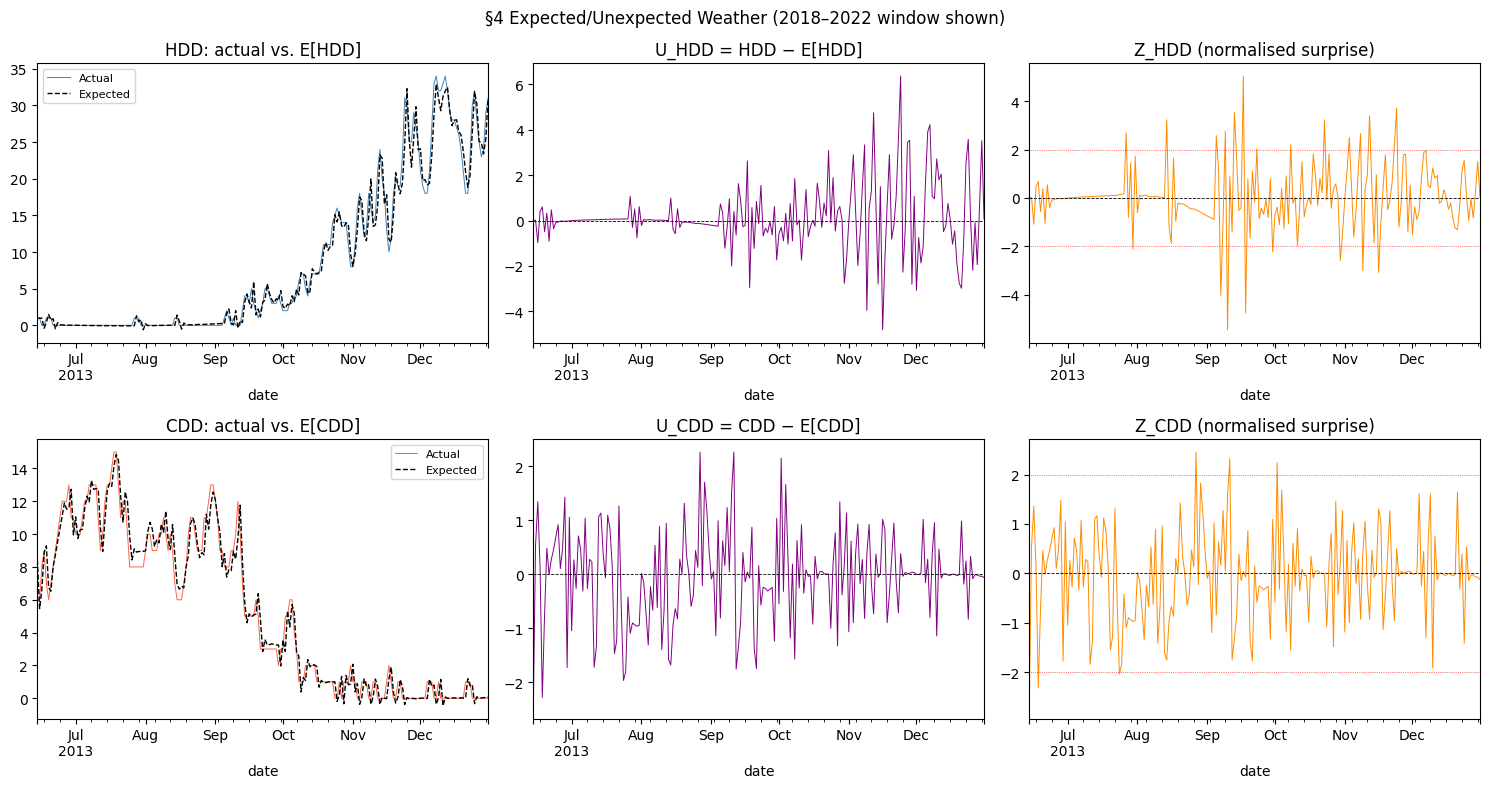

In [14]:
# Model quality: actual vs predicted for HDD and CDD
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(['HDD', 'CDD']):
    row = i
    plot_slice = df.loc['2010':'2013', [col, f'E_{col}', f'U_{col}', f'Z_{col}']].dropna()

    # Actual vs Expected
    ax = axes[row, 0]
    plot_slice[col].plot(ax=ax, lw=0.7, color='steelblue' if col=='HDD' else 'tomato', label='Actual')
    plot_slice[f'E_{col}'].plot(ax=ax, lw=1.0, color='k', ls='--', label='Expected')
    ax.set_title(f'{col}: actual vs. E[{col}]')
    ax.legend(fontsize=8)

    # Surprise
    ax = axes[row, 1]
    plot_slice[f'U_{col}'].plot(ax=ax, lw=0.7, color='purple')
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(f'U_{col} = {col} − E[{col}]')

    # Z-score
    ax = axes[row, 2]
    plot_slice[f'Z_{col}'].plot(ax=ax, lw=0.7, color='darkorange')
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.axhline( 2, color='r', lw=0.5, ls=':')
    ax.axhline(-2, color='r', lw=0.5, ls=':')
    ax.set_title(f'Z_{col} (normalised surprise)')

plt.suptitle('§4 Expected/Unexpected Weather (2018–2022 window shown)', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# Model fit quality: RMSE and R² of the ARMAX predictions
from sklearn.metrics import r2_score, mean_squared_error

print('ARMAX model quality (out-of-sample, i.e. after first fit):')
print(f'{"Variable":<12}  {"RMSE":>8}  {"R²":>8}  {"Corr":>8}  {"Mean|Z|":>10}')
print('-' * 52)
for col in exp_cols:
    mask = df[col].notna() & df[f'E_{col}'].notna()
    if mask.sum() < 100:
        continue
    actual = df.loc[mask, col]
    pred   = df.loc[mask, f'E_{col}']
    rmse   = np.sqrt(mean_squared_error(actual, pred))
    r2     = r2_score(actual, pred)
    corr   = actual.corr(pred)
    mz     = df.loc[mask, f'Z_{col}'].abs().mean()
    print(f'{col:<12}  {rmse:>8.3f}  {r2:>8.3f}  {corr:>8.3f}  {mz:>10.3f}')

ARMAX model quality (out-of-sample, i.e. after first fit):
Variable          RMSE        R²      Corr     Mean|Z|
----------------------------------------------------
HDD              1.692     0.975     0.988       0.853
CDD              0.688     0.975     0.987       0.733
HDD2            78.736     0.942     0.971       0.950
CDD2            10.744     0.957     0.978       0.934


## §5 — 5-Day-Ahead Forecast Weather Shock

The futures market prices 5-day-ahead weather conditions. We generate a recursive multi-step forecast at $t$ and compare to the climate normal:

$$WHDD_{5d,t} = \frac{1}{5} \sum_{m=1}^{5} \Bigl[ \hat{E}_t[HDD_{t+m}] - \bar{HDD}_{\text{normal},t+m} \Bigr]$$

where $\hat{E}_t[\cdot]$ is the **recursive ARMAX forecast** made at $t$ (model trained on $[0, t-1]$),  
and $\bar{HDD}_{\text{normal},t+m}$ is the climate normal for the future calendar date $t+m$ (known at $t$ from history).

**Interpretation:**
- $WHDD_{5d,t} > 0$: next 5 days colder than normal → excess demand → bullish for near maturities
- $WCDD_{5d,t} > 0$: next 5 days hotter than normal → excess cooling demand

**No lookahead:** future Fourier terms and climate normals are computed from past data only.

In [16]:
from features.fundamental import add_forecast_weather_shock_features

print('Computing 5-day-ahead forecast shocks...')
df = add_forecast_weather_shock_features(
    df, cols=['HDD', 'CDD'], horizon=5,
    normal_suffix=SUFFIX, ar_lags=[1,2,3,5,10],
    train_min_obs=500, refit_frequency=20,
)

shock_cols = [c for c in df.columns if c.startswith('W') and ('HDD' in c or 'CDD' in c)]
print('Forecast shock columns:', shock_cols)
df[shock_cols].dropna().describe().round(3)

Computing 5-day-ahead forecast shocks...
Forecast shock columns: ['WHDD_5d', 'WHDD2_5d', 'WCDD_5d', 'WCDD2_5d']


,WHDD_5d,WHDD2_5d,WCDD_5d,WCDD2_5d
count,4671.000,4671.000,4671.000,4671.000
mean,0.005,4.364,-0.036,0.509
std,2.089,9.432,0.713,1.123
min,-9.470,0.000,-3.900,0.000
25%,-0.805,0.085,-0.355,0.022
50%,-0.059,0.661,-0.034,0.108
75%,0.825,4.024,0.305,0.451
max,11.648,135.683,3.541,15.212


In [17]:
df[shock_cols].loc['2013-05-15':].dropna()

,WHDD_5d,WHDD2_5d,WCDD_5d,WCDD2_5d
date,,,,
2013-05-15,-0.973,0.947,0.782,0.612
2013-05-16,-0.619,0.383,0.983,0.965
2013-05-17,0.167,0.028,0.464,0.216
2013-05-18,-0.340,0.115,0.191,0.036
2013-05-19,-0.601,0.361,0.554,0.307
...,...,...,...,...
2026-02-22,2.727,7.435,-0.590,0.348
2026-02-23,4.374,19.134,-0.375,0.141
2026-02-24,2.069,4.283,-0.354,0.125


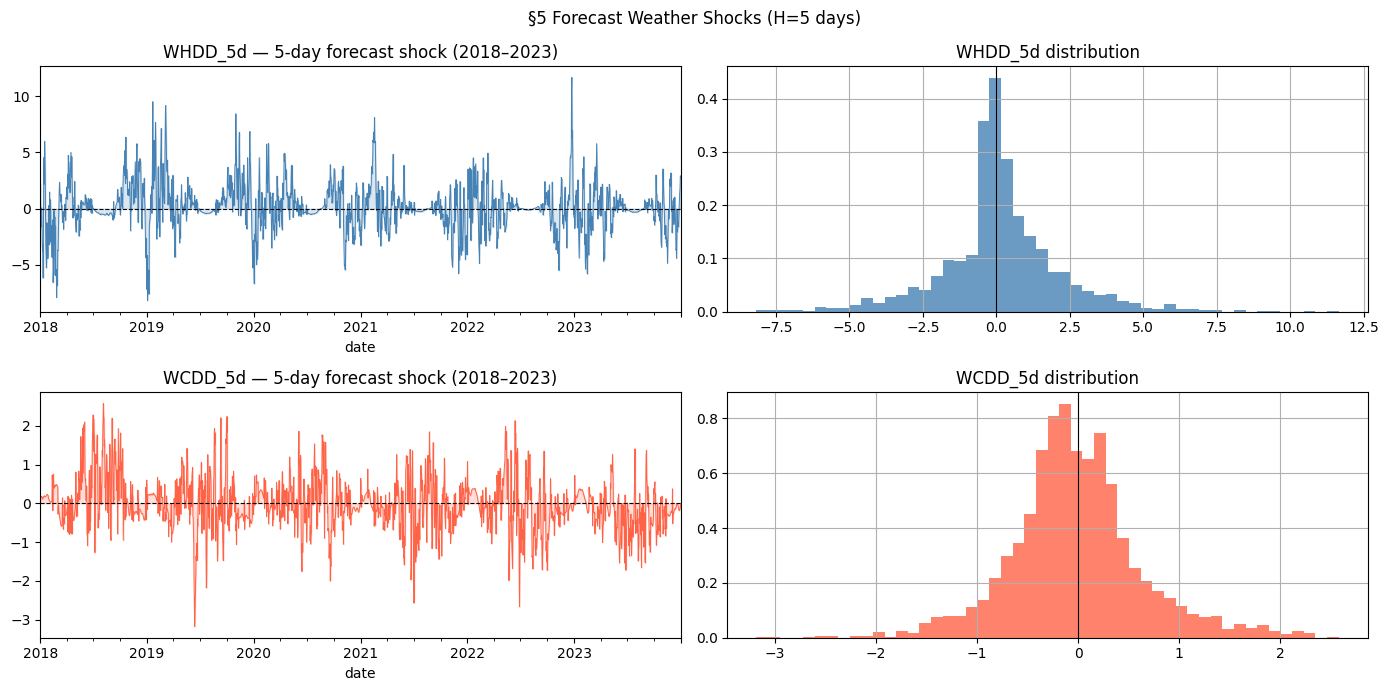

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for i, col in enumerate(['HDD', 'CDD']):
    w_col = f'W{col}_5d'
    plot_data = df.loc['2018':'2023', w_col].dropna()

    ax = axes[i, 0]
    plot_data.plot(ax=ax, lw=0.7, color='steelblue' if col=='HDD' else 'tomato')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.fill_between(plot_data.index, plot_data, 0, alpha=0.2,
                    color='steelblue' if col=='HDD' else 'tomato')
    ax.set_title(f'W{col}_5d — 5-day forecast shock (2018–2023)')

    ax = axes[i, 1]
    plot_data.hist(ax=ax, bins=50, density=True, color='steelblue' if col=='HDD' else 'tomato',
                   edgecolor='none', alpha=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'W{col}_5d distribution')

plt.suptitle('§5 Forecast Weather Shocks (H=5 days)', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
# Validate: do forecast shocks predict next 5-day actual anomaly?
# (Pure diagnostic — NOT using future HDD in features, only checking signal quality)
actual_anom_5d = df['HDD_anom_normal'].rolling(5).mean().shift(-5)  # future 5-day avg anomaly

mask = df['WHDD_5d'].notna() & actual_anom_5d.notna()
r = df.loc[mask, 'WHDD_5d'].corr(actual_anom_5d[mask])
print(f'Corr(WHDD_5d_t, avg_HDD_anom_{{t+1..t+5}}): {r:.3f}')
print('(Expected > 0 — forecast should track actual future anomaly)')

Corr(WHDD_5d_t, avg_HDD_anom_{t+1..t+5}): 0.632
(Expected > 0 — forecast should track actual future anomaly)


In [20]:
actual_cdd_anom_5d = df['CDD_anom_normal'].rolling(5).mean().shift(-5)

mask = df['WCDD_5d'].notna() & actual_cdd_anom_5d.notna()
r = df.loc[mask, 'WCDD_5d'].corr(actual_cdd_anom_5d[mask])

print(f'Corr(WCDD_5d_t, avg_CDD_anom_{{t+1..t+5}}): {r:.3f}')

Corr(WCDD_5d_t, avg_CDD_anom_{t+1..t+5}): 0.609


In [21]:
baseline = df['HDD_anom_normal']
mask = baseline.notna() & actual_anom_5d.notna()

r_base = baseline[mask].corr(actual_anom_5d[mask])
print(f'Baseline corr(HDD_anom_t, future avg anomaly): {r_base:.3f}')

baseline = df['CDD_anom_normal']
mask = baseline.notna() & actual_cdd_anom_5d.notna()

r_base = baseline[mask].corr(actual_cdd_anom_5d[mask])
print(f'Baseline corr(CDD_anom_t, future avg anomaly): {r_base:.3f}')

Baseline corr(HDD_anom_t, future avg anomaly): 0.617
Baseline corr(CDD_anom_t, future avg anomaly): 0.557


Donc WHDD_5d prédit bien l’anomalie future, mais il améliore seulement légèrement le baseline simple HDD_anom_t. Un peu mieux pour CDD

## §6 — EIA Storage Announcements

EIA publishes CONUS working gas storage **weekly** (7-day intervals). The forward-filled daily series has $\Delta\text{Storage}_t \neq 0$ only on release days.

$$\Delta\text{Storage}_a = \text{Storage}_a - \text{Storage}_{a-1}$$

where $a$ and $a-1$ are consecutive announcement dates. This is the **actual build/draw** for the week.

**Key intuition:** a larger-than-expected draw (bearish storage) → tighter near-term supply → price pressure on front maturities.

In [22]:
from features.fundamental import build_storage_announcement_table

ann = build_storage_announcement_table(df)

print(f'Announcement table: {len(ann)} weekly releases')
print(f'Date range: {ann.index[0].date()} → {ann.index[-1].date()}')
print(f'\nWindow days — always 7 days: {ann["window_days"].unique().tolist()}')
print()
ann[['storage_bcf', 'delta_storage_bcf']].describe().round(1)

Announcement table: 841 weekly releases
Date range: 2010-01-15 → 2026-02-20

Window days — always 7 days: [7.0]



,storage_bcf,delta_storage_bcf
count,841.000,841.000
mean,2768.700,-1.000
std,740.900,99.100
min,824.000,-360.000
25%,2233.000,-63.000
50%,2822.000,34.000
75%,3369.000,76.000
max,4047.000,132.000


In [23]:
ann

,storage_bcf,delta_storage_bcf,ann_prev,window_days
ann_date,,,,
2010-01-15,2607.000,-243.000,2010-01-08,7.000
2010-01-22,2521.000,-86.000,2010-01-15,7.000
2010-01-29,2406.000,-115.000,2010-01-22,7.000
2010-02-05,2214.000,-192.000,2010-01-29,7.000
2010-02-12,2026.000,-188.000,2010-02-05,7.000
...,...,...,...,...
2026-01-23,2823.000,-242.000,2026-01-16,7.000
2026-01-30,2463.000,-360.000,2026-01-23,7.000
2026-02-06,2214.000,-249.000,2026-01-30,7.000


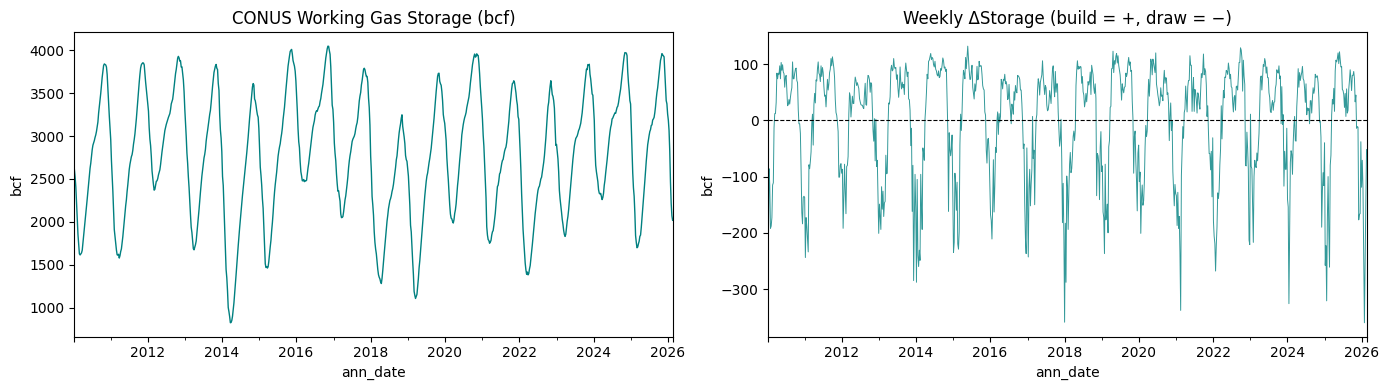

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ann['storage_bcf'].plot(ax=axes[0], lw=1.0, color='teal')
axes[0].set_title('CONUS Working Gas Storage (bcf)')
axes[0].set_ylabel('bcf')

ann['delta_storage_bcf'].plot(ax=axes[1], lw=0.7, color='teal', alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_title('Weekly ΔStorage (build = +, draw = −)')
axes[1].set_ylabel('bcf')

plt.tight_layout()
plt.show()

## §7 — Weather Aggregated Over the Storage Window

The EIA storage change between announcements $a_{\text{prev}}$ and $a$ is driven by weather during that 7-day window. We aggregate:

$$HDD_{\text{storage-window},a} = \sum_{t \in (a_{\text{prev}},\, a]} HDD_t$$

Similarly for CDD, HDD², CDD², HDD_inc, CDD_inc and their variances.  
These become regressors in the expected storage change model (§8).

In [25]:
from features.fundamental import add_storage_window_weather_features

ann = add_storage_window_weather_features(df, ann)

wx_win_cols = [c for c in ann.columns if 'storage_window' in c]
print(f'Added {len(wx_win_cols)} weather-window features to announcement table')
ann[wx_win_cols].describe().round(1)

Added 8 weather-window features to announcement table


,HDD_storage_window,HDD_var_storage_window,HDD2_storage_window,HDD2_var_storage_window,CDD_storage_window,CDD_var_storage_window,CDD2_storage_window,CDD2_var_storage_window
count,841.000,841.000,841.000,841.000,841.000,841.000,841.000,841.000
mean,79.200,5.900,1702.200,11969.700,26.500,0.800,235.300,233.000
std,73.500,9.200,2176.400,29196.700,30.200,1.300,357.600,507.600
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,7.000,0.200,7.000,1.300,2.000,0.100,2.000,0.100
50%,62.000,2.500,590.000,791.100,10.000,0.300,18.000,2.600
75%,143.000,8.100,2976.000,10857.300,51.000,1.000,379.000,209.000
max,274.000,88.000,10778.000,333027.700,101.000,9.600,1463.000,4715.000


In [26]:
ann

,storage_bcf,delta_storage_bcf,ann_prev,window_days,HDD_storage_window,HDD_var_storage_window,HDD2_storage_window,HDD2_var_storage_window,CDD_storage_window,CDD_var_storage_window,CDD2_storage_window,CDD2_var_storage_window
ann_date,,,,,,,,,,,,
2010-01-15,2607.000,-243.000,2010-01-08,7.000,225,31.143,7419,126319.143,0,0.000,0,0.000
2010-01-22,2521.000,-86.000,2010-01-15,7.000,161,0.333,3705,705.571,0,0.000,0,0.000
2010-01-29,2406.000,-115.000,2010-01-22,7.000,182,22.000,4864,64351.143,0,0.000,0,0.000
2010-02-05,2214.000,-192.000,2010-01-29,7.000,216,14.810,6754,57634.143,0,0.000,0,0.000
2010-02-12,2026.000,-188.000,2010-02-05,7.000,220,2.619,6930,9617.000,0,0.000,0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-23,2823.000,-242.000,2026-01-16,7.000,217,4.667,6755,17952.667,0,0.000,0,0.000
2026-01-30,2463.000,-360.000,2026-01-23,7.000,273,4.000,10671,23876.286,0,0.000,0,0.000
2026-02-06,2214.000,-249.000,2026-01-30,7.000,223,18.143,7213,78123.286,0,0.000,0,0.000


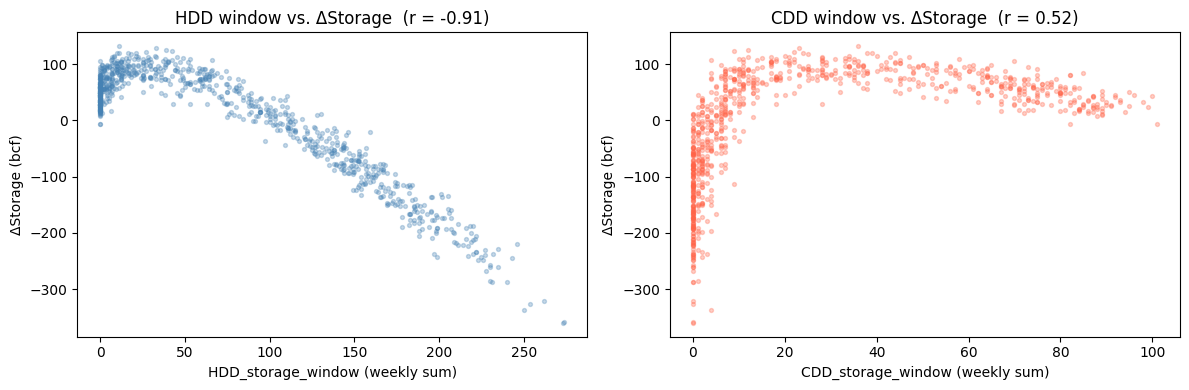

In [27]:
# How well does weather in the window explain ΔStorage?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(ann['HDD_storage_window'], ann['delta_storage_bcf'],
           alpha=0.3, s=8, color='steelblue')
ax.set_xlabel('HDD_storage_window (weekly sum)')
ax.set_ylabel('ΔStorage (bcf)')
r_hdd = ann['HDD_storage_window'].corr(ann['delta_storage_bcf'])
ax.set_title(f'HDD window vs. ΔStorage  (r = {r_hdd:.2f})')

ax = axes[1]
ax.scatter(ann['CDD_storage_window'], ann['delta_storage_bcf'],
           alpha=0.3, s=8, color='tomato')
ax.set_xlabel('CDD_storage_window (weekly sum)')
ax.set_ylabel('ΔStorage (bcf)')
r_cdd = ann['CDD_storage_window'].corr(ann['delta_storage_bcf'])
ax.set_title(f'CDD window vs. ΔStorage  (r = {r_cdd:.2f})')

plt.tight_layout()
plt.show()

- HDD faible → injection possible, ΔStorage positif
- HDD élevé → withdrawal, ΔStorage négatif

- HDD weekly sum est une excellente variable pour expliquer les withdrawals.
- CDD weekly sum est utile, mais doit être interprété après contrôle de la saisonnalité.

## §8 — Expected / Unexpected Storage Change

A market-implied consensus for $\Delta\text{Storage}_a$ can be estimated from observable predictors:

$$\hat{E}[\Delta S_a] = \mu + \beta_1\, \overline{\Delta S}_{\text{normal},a} + \sum_k \beta_k \, \text{weather}_{\text{window},a} + \sum_{l=1}^{4} \varphi_l \Delta S_{a-l} + \text{month dummies} + \varepsilon_a$$

Fit in **expanding window** on announcement-frequency data, refitted every 4 releases (~monthly).

**Storage surprise:**
$$U_{\Delta S,a} = \Delta S_a - \hat{E}[\Delta S_a]$$

$$Z_{\Delta S,a} = \frac{U_{\Delta S,a}}{\hat{\sigma}_{\Delta S,a}}$$

These are then **forward-filled** to the daily panel, available from announcement day $a$ onward.

In [28]:
from features.fundamental import add_expected_unexpected_storage_features

ann = add_expected_unexpected_storage_features(
    ann, lookback_years=5, day_window=7,
    train_min_obs=30, refit_frequency=4, rolling_sigma_window=26,
)

mask = ann['E_DeltaStorage'].notna()
print(f'Storage E/U/Z computed for {mask.sum()} of {len(ann)} announcements')
ann[['delta_storage_bcf', 'E_DeltaStorage', 'U_DeltaStorage', 'Z_DeltaStorage']].describe().round(2)

Storage E/U/Z computed for 811 of 841 announcements


,delta_storage_bcf,E_DeltaStorage,U_DeltaStorage,Z_DeltaStorage
count,841.000,811.000,811.000,798.000
mean,-0.990,0.340,-1.530,-0.120
std,99.060,98.810,21.480,1.410
min,-360.000,-393.290,-80.090,-5.820
25%,-63.000,-66.120,-16.880,-1.080
50%,34.000,39.800,-2.430,-0.150
75%,76.000,76.440,13.230,0.790
max,132.000,125.940,79.060,4.950


Storage model R² = 0.953  |  corr(actual, predicted) = 0.976


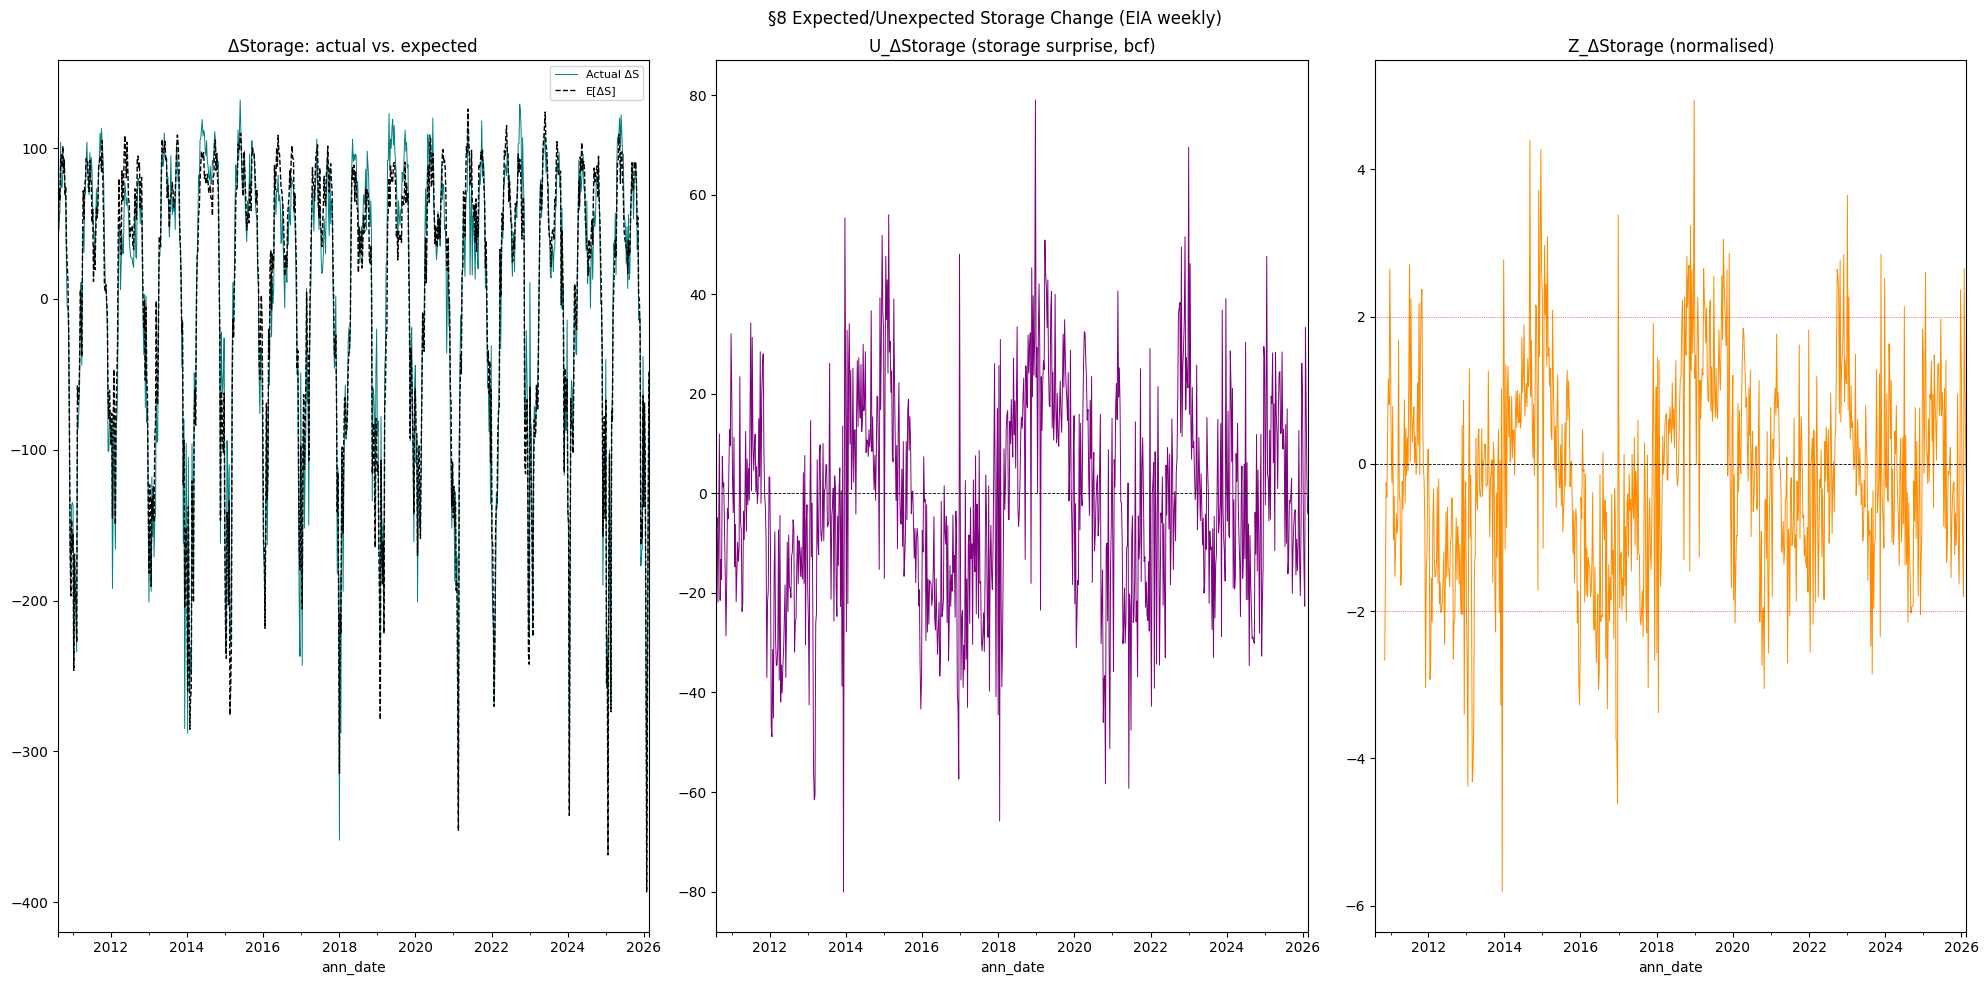

In [29]:
# Model quality: actual vs. expected ΔStorage
from sklearn.metrics import r2_score
mask = ann['E_DeltaStorage'].notna() & ann['delta_storage_bcf'].notna()
r2   = r2_score(ann.loc[mask,'delta_storage_bcf'], ann.loc[mask,'E_DeltaStorage'])
corr = ann.loc[mask,'delta_storage_bcf'].corr(ann.loc[mask,'E_DeltaStorage'])
print(f'Storage model R² = {r2:.3f}  |  corr(actual, predicted) = {corr:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# Actual vs Expected
ax = axes[0]
ann.loc[mask, 'delta_storage_bcf'].plot(ax=ax, lw=0.7, color='teal', label='Actual ΔS')
ann.loc[mask, 'E_DeltaStorage'].plot(ax=ax, lw=1.0, color='k', ls='--', label='E[ΔS]')
ax.set_title('ΔStorage: actual vs. expected')
ax.legend(fontsize=8)

# Surprise
ax = axes[1]
ann.loc[mask, 'U_DeltaStorage'].plot(ax=ax, lw=0.7, color='purple')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_title('U_ΔStorage (storage surprise, bcf)')

# Z-score
ax = axes[2]
ann.loc[mask, 'Z_DeltaStorage'].plot(ax=ax, lw=0.7, color='darkorange')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.axhline( 2, color='r', lw=0.5, ls=':')
ax.axhline(-2, color='r', lw=0.5, ls=':')
ax.set_title('Z_ΔStorage (normalised)')

plt.suptitle('§8 Expected/Unexpected Storage Change (EIA weekly)', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
ann

,storage_bcf,delta_storage_bcf,ann_prev,window_days,HDD_storage_window,HDD_var_storage_window,HDD2_storage_window,HDD2_var_storage_window,CDD_storage_window,CDD_var_storage_window,CDD2_storage_window,CDD2_var_storage_window,StorageChange_normal,delta_storage_ar_1,delta_storage_ar_2,delta_storage_ar_3,delta_storage_ar_4,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,E_DeltaStorage,U_DeltaStorage,Z_DeltaStorage
ann_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-15,2607.000,-243.000,2010-01-08,7.000,225,31.143,7419,126319.143,0,0.000,0,0.000,NaN,NaN,NaN,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-01-22,2521.000,-86.000,2010-01-15,7.000,161,0.333,3705,705.571,0,0.000,0,0.000,NaN,-243.000,NaN,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-01-29,2406.000,-115.000,2010-01-22,7.000,182,22.000,4864,64351.143,0,0.000,0,0.000,NaN,-86.000,-243.000,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-02-05,2214.000,-192.000,2010-01-29,7.000,216,14.810,6754,57634.143,0,0.000,0,0.000,NaN,-115.000,-86.000,-243.000,NaN,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-02-12,2026.000,-188.000,2010-02-05,7.000,220,2.619,6930,9617.000,0,0.000,0,0.000,NaN,-192.000,-115.000,-86.000,-243.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-23,2823.000,-242.000,2026-01-16,7.000,217,4.667,6755,17952.667,0,0.000,0,0.000,-211.100,-120.000,-71.000,-119.000,-38.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-219.337,-22.663,-1.799
2026-01-30,2463.000,-360.000,2026-01-23,7.000,273,4.000,10671,23876.286,0,0.000,0,0.000,-198.800,-242.000,-120.000,-71.000,-119.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-393.291,33.291,2.652
2026-02-06,2214.000,-249.000,2026-01-30,7.000,223,18.143,7213,78123.286,0,0.000,0,0.000,-154.000,-360.000,-242.000,-120.000,-71.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-265.835,16.835,1.151


## §9 — Daily Panel Merge + Summary

Storage announcement features are **forward-filled** to the daily panel. We also create **timing dummies** to capture how the market absorbs the storage surprise over the days following the release:

$$D_{\text{storage},k,t} = \mathbf{1}[\text{bdays-since-last-ann}(t) = k], \quad k \in \{0,1,2,3\}$$

**Interaction features:**
$$U\text{Storage} \times D_{k,t} = U_{\Delta S,\text{last}} \cdot D_{\text{storage},k,t}$$

These interactions allow the ML model to learn that a large storage surprise has different impact on day 0 (immediate price reaction) vs. day 3 (drift or reversal).

In [31]:
from features.fundamental import merge_storage_features_back_to_daily

df = merge_storage_features_back_to_daily(df, ann)

storage_daily_cols = [
    'Storage', 'DeltaStorage_last', 'is_storage_announcement_day',
    'days_since_storage_announcement',
    'E_DeltaStorage_last', 'U_DeltaStorage_last', 'Z_DeltaStorage_last',
    'D_storage_0', 'D_storage_1', 'D_storage_2', 'D_storage_3', 'D_storage_4plus',
    'UStorage_x_D0', 'UStorage_x_D1', 'UStorage_x_D2', 'UStorage_x_D3',
    'EStorage_x_D0', 'EStorage_x_D1', 'EStorage_x_D2', 'EStorage_x_D3',
]

print('Storage daily features:')
df[storage_daily_cols].describe().round(2)

Storage daily features:


,Storage,DeltaStorage_last,is_storage_announcement_day,days_since_storage_announcement,E_DeltaStorage_last,U_DeltaStorage_last,Z_DeltaStorage_last,D_storage_0,D_storage_1,D_storage_2,D_storage_3,D_storage_4plus,UStorage_x_D0,UStorage_x_D1,UStorage_x_D2,UStorage_x_D3,EStorage_x_D0,EStorage_x_D1,EStorage_x_D2,EStorage_x_D3
count,5895.000,5892.000,5906.000,4208.000,5682.000,5682.000,5591.000,5906.000,5906.000,5906.000,5906.000,5906.000,5682.000,5682.000,5682.000,5682.000,5682.000,5682.000,5682.000,5682.000
mean,2769.990,-1.030,0.140,2.000,0.300,-1.540,-0.120,0.140,0.140,0.140,0.140,0.140,-0.220,-0.220,-0.220,-0.220,0.050,0.050,0.050,0.050
std,739.750,98.980,0.350,1.420,98.720,21.460,1.410,0.350,0.350,0.350,0.350,0.350,8.130,8.130,8.130,8.130,37.310,37.310,37.310,37.310
min,824.000,-360.000,0.000,0.000,-393.290,-80.090,-5.820,0.000,0.000,0.000,0.000,0.000,-80.090,-80.090,-80.090,-80.090,-393.290,-393.290,-393.290,-393.290
25%,2240.000,-63.000,0.000,1.000,-66.130,-16.980,-1.080,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,2823.000,34.000,0.000,2.000,39.800,-2.430,-0.150,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
75%,3369.000,76.000,0.000,3.000,76.460,13.290,0.790,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,0.000
max,4047.000,132.000,1.000,7.000,125.940,79.060,4.950,1.000,1.000,1.000,1.000,1.000,79.060,79.060,79.060,79.060,125.940,125.940,125.940,125.940


In [32]:
df[['is_storage_announcement_day','days_since_storage_announcement',]].head(30)

,is_storage_announcement_day,days_since_storage_announcement
date,,
2010-01-01,0,NaN
2010-01-02,0,NaN
2010-01-03,0,NaN
2010-01-04,0,NaN
2010-01-05,0,NaN
2010-01-06,0,NaN
2010-01-07,0,NaN
2010-01-08,0,NaN
2010-01-09,0,NaN


In [33]:
ann.index.day_name().value_counts()

ann_date
Friday    841
Name: count, dtype: int64

In [34]:
# Verify timing dummies: they should sum to 1 on any given date
timing_cols = ['D_storage_0','D_storage_1','D_storage_2','D_storage_3','D_storage_4plus']
dummy_sum   = df[timing_cols].sum(axis=1)
# Calendar days may not all be business days — some rows have NaN days_since
valid_rows = df['days_since_storage_announcement'].notna()
print('Timing dummy sum (should be 1 on all rows with known days_since):')
print(dummy_sum[valid_rows].value_counts())

Timing dummy sum (should be 1 on all rows with known days_since):
1.000    4208
Name: count, dtype: int64


In [35]:
# Full panel overview
from features.fundamental import FAMILY_B_COLS

present_cols = [c for c in FAMILY_B_COLS if c in df.columns]
missing_cols = [c for c in FAMILY_B_COLS if c not in df.columns]

print(f'FAMILY_B_COLS present in panel : {len(present_cols)} / {len(FAMILY_B_COLS)}')
if missing_cols:
    print(f'Missing: {missing_cols}')

print(f'\nPanel shape: {df.shape}')
print(f'Date range : {df.index[0].date()} → {df.index[-1].date()}')

# NaN summary for declared family B cols
nan_pct = df[present_cols].isna().mean().mul(100).sort_values(ascending=False).round(1)
print('\nNaN% per feature (sorted):')
print(nan_pct[nan_pct > 0].to_string())

FAMILY_B_COLS present in panel : 57 / 57

Panel shape: (5906, 62)
Date range : 2010-01-01 → 2026-03-03

NaN% per feature (sorted):
days_since_storage_announcement   28.800
Z_HDD                             21.300
Z_CDD                             21.300
Z_CDD2                            21.300
Z_HDD2                            21.300
WHDD_5d                           20.900
WCDD_5d                           20.900
WHDD2_5d                          20.900
WCDD2_5d                          20.900
U_HDD                             20.800
E_CDD2                            20.800
E_HDD                             20.800
U_CDD2                            20.800
E_CDD                             20.800
U_CDD                             20.800
E_HDD2                            20.800
U_HDD2                            20.800
HDD_anom_normal                   12.400
CDD2_anom_normal                  12.400
HDD2_anom_normal                  12.400
CDD_anom_normal                   12.400
CDD_norm

Computing Spearman correlation on 57 features...


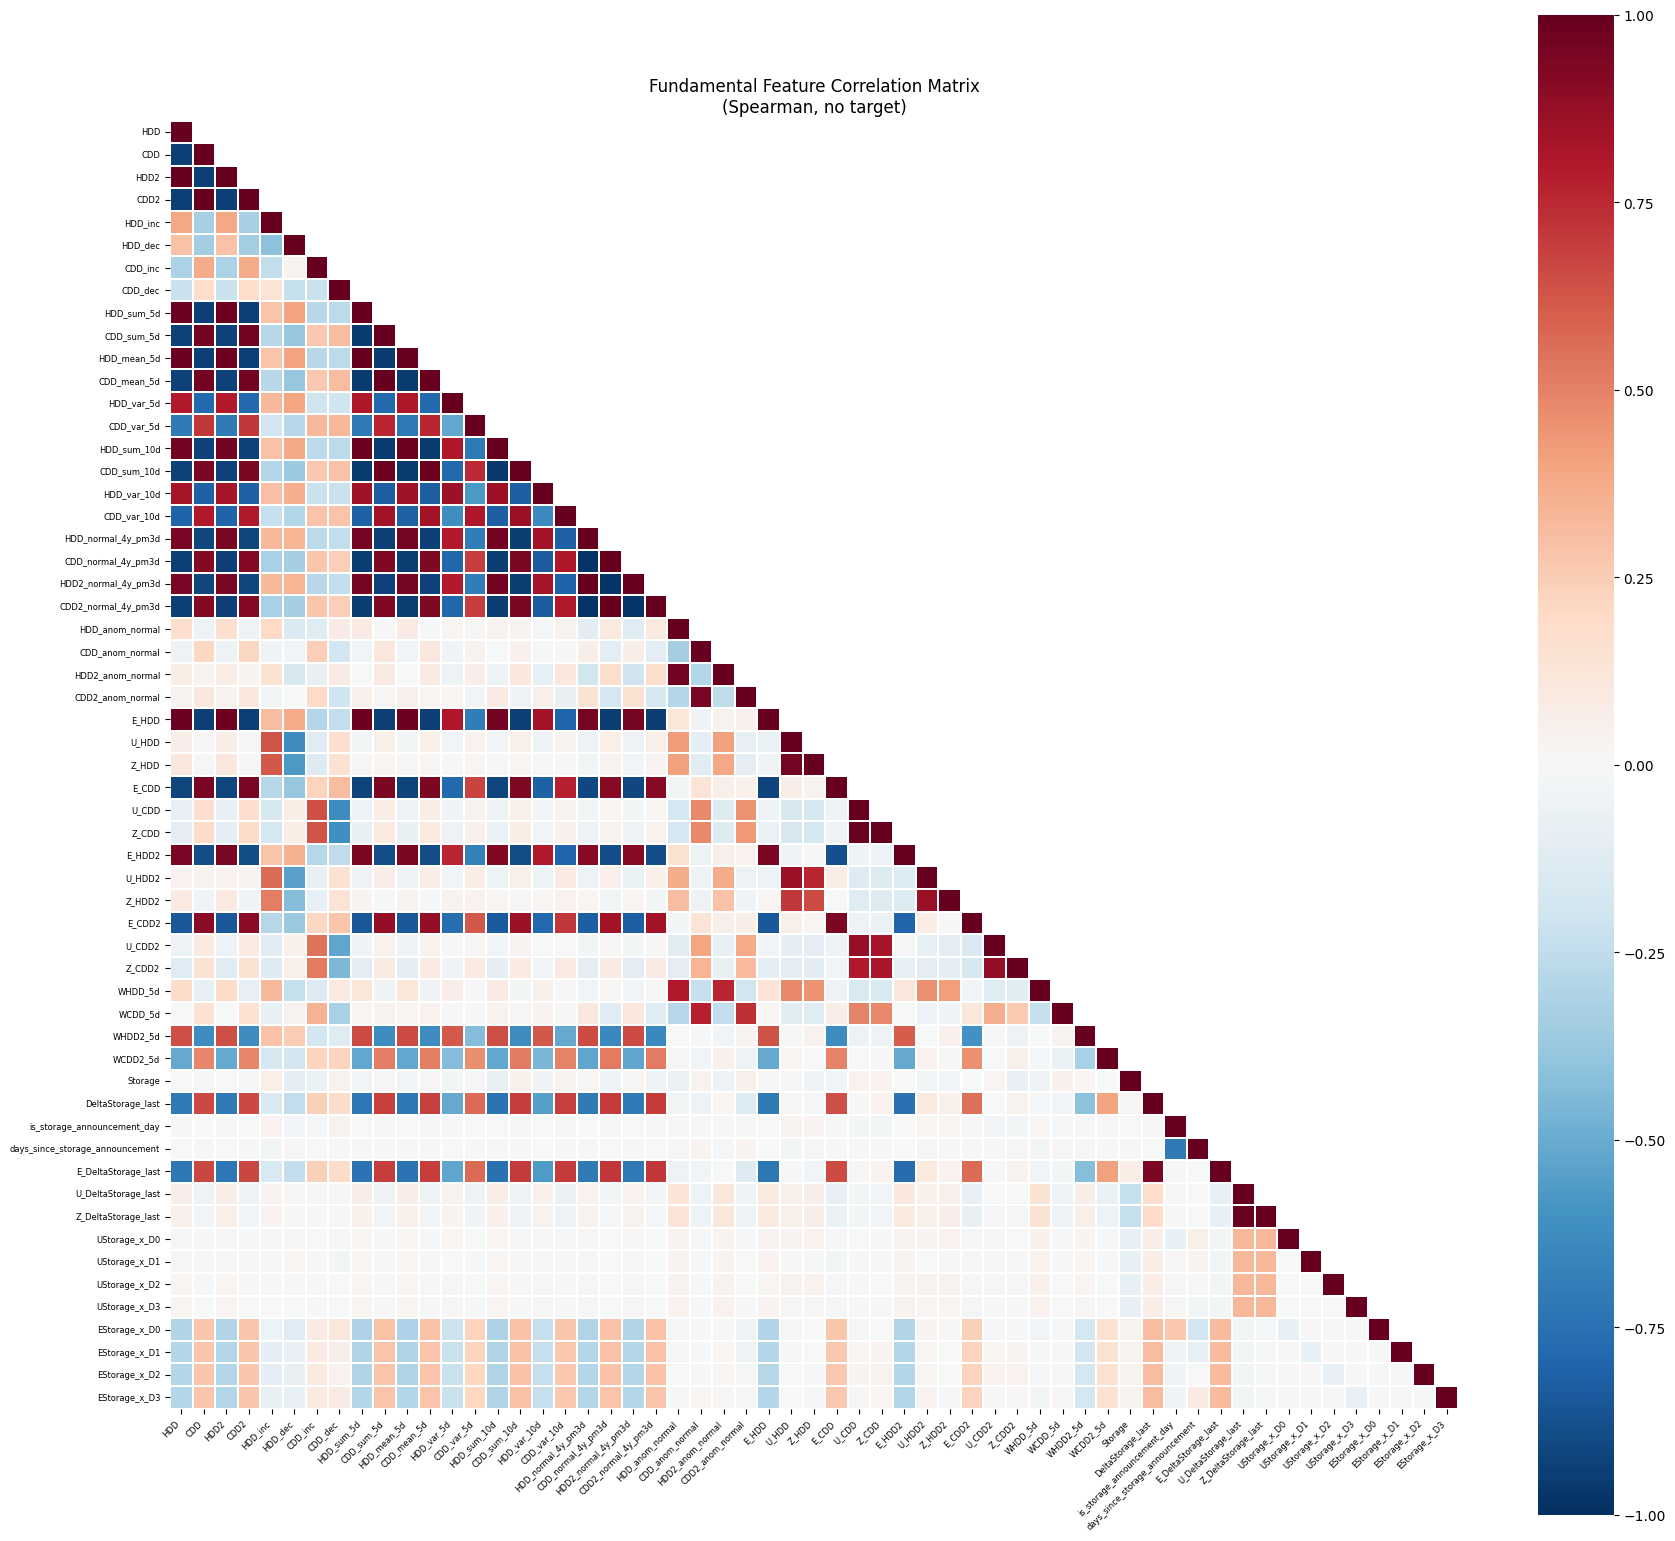

In [36]:
# Feature correlation matrix — fundamental features only, no target
feat_for_corr = [c for c in present_cols if df[c].notna().sum() > 500]

print(f'Computing Spearman correlation on {len(feat_for_corr)} features...')
df_corr = df[feat_for_corr].rank(pct=True).corr(method='pearson')

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1)
sns.heatmap(df_corr, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.3, ax=ax)
ax.set_title('Fundamental Feature Correlation Matrix\n(Spearman, no target)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

In [37]:
# Highly correlated pairs (|ρ| ≥ 0.85)
pairs = (
    df_corr
    .where(np.tril(np.ones(df_corr.shape), k=-1).astype(bool))
    .stack().abs().sort_values(ascending=False)
    .rename('|rho|').reset_index()
    .rename(columns={'level_0':'feat_1','level_1':'feat_2'})
)
high = pairs[pairs['|rho|'] >= 0.85]
print(f'{len(high)} pairs with |ρ| ≥ 0.85:')
display(high.head(20))

155 pairs with |ρ| ≥ 0.85:


,feat_1,feat_2,|rho|
0,CDD_mean_5d,CDD_sum_5d,1.000
1,CDD2,CDD,1.000
2,HDD2,HDD,1.000
3,HDD_mean_5d,HDD_sum_5d,1.000
4,HDD2_normal_4y_pm3d,HDD_normal_4y_pm3d,1.000
5,CDD2_normal_4y_pm3d,CDD_normal_4y_pm3d,1.000
6,HDD_sum_10d,HDD_mean_5d,0.989
7,HDD_sum_10d,HDD_sum_5d,0.989
8,Z_CDD,U_CDD,0.986
9,Z_DeltaStorage_last,U_DeltaStorage_last,0.986


In [38]:
df.loc["2014-01-01":].isna().sum().sort_values(ascending=False)

days_since_storage_announcement    1270
Storage                              11
WHDD_5d                               5
WHDD2_5d                              5
WCDD_5d                               5
                                   ... 
CDD2_anom_normal                      0
E_HDD                                 0
U_HDD                                 0
Z_HDD                                 0
EStorage_x_D3                         0
Length: 62, dtype: int64

In [39]:
df

,HDD,CDD,Storage,HDD2,CDD2,HDD_inc,HDD_dec,CDD_inc,CDD_dec,HDD_sum_5d,HDD_mean_5d,HDD_var_5d,HDD_sum_10d,HDD_var_10d,CDD_sum_5d,CDD_mean_5d,CDD_var_5d,CDD_sum_10d,CDD_var_10d,HDD_normal_4y_pm3d,...,WCDD2_5d,is_storage_announcement_day,days_since_storage_announcement,DeltaStorage_last,E_DeltaStorage_last,U_DeltaStorage_last,Z_DeltaStorage_last,D_storage_0,D_storage_1,D_storage_2,D_storage_3,D_storage_4plus,UStorage_x_D0,EStorage_x_D0,UStorage_x_D1,EStorage_x_D1,UStorage_x_D2,EStorage_x_D2,UStorage_x_D3,EStorage_x_D3
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01,30,0,3117.000,900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02,35,0,3117.000,1225,0,5.000,0.000,0.000,-0.000,NaN,NaN,12.500,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-03,38,0,3117.000,1444,0,3.000,0.000,0.000,-0.000,103.000,34.333,16.333,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,37,0,3117.000,1369,0,0.000,1.000,0.000,-0.000,140.000,35.000,12.667,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,36,0,3117.000,1296,0,0.000,1.000,0.000,-0.000,176.000,35.200,9.700,176.000,9.700,0.000,0.000,0.000,0.000,0.000,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-27,16,1,NaN,256,1,0.000,3.000,1.000,0.000,114.000,22.800,29.200,220.000,18.889,1.000,0.200,0.200,4.000,0.267,20.857,...,NaN,0,5.000,-52.000,-47.956,-4.044,-0.280,0.000,0.000,0.000,0.000,1.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
2026-02-28,16,1,NaN,256,1,0.000,-0.000,0.000,-0.000,101.000,20.200,22.700,218.000,21.067,2.000,0.400,0.300,5.000,0.278,20.321,...,NaN,0,NaN,-52.000,-47.956,-4.044,-0.280,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
2026-03-01,19,1,NaN,361,1,3.000,0.000,0.000,-0.000,93.000,18.600,8.300,219.000,20.322,3.000,0.600,0.300,5.000,0.278,19.643,...,NaN,0,NaN,-52.000,-47.956,-4.044,-0.280,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000


In [40]:
ann

,storage_bcf,delta_storage_bcf,ann_prev,window_days,HDD_storage_window,HDD_var_storage_window,HDD2_storage_window,HDD2_var_storage_window,CDD_storage_window,CDD_var_storage_window,CDD2_storage_window,CDD2_var_storage_window,StorageChange_normal,delta_storage_ar_1,delta_storage_ar_2,delta_storage_ar_3,delta_storage_ar_4,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,E_DeltaStorage,U_DeltaStorage,Z_DeltaStorage
ann_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-15,2607.000,-243.000,2010-01-08,7.000,225,31.143,7419,126319.143,0,0.000,0,0.000,NaN,NaN,NaN,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-01-22,2521.000,-86.000,2010-01-15,7.000,161,0.333,3705,705.571,0,0.000,0,0.000,NaN,-243.000,NaN,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-01-29,2406.000,-115.000,2010-01-22,7.000,182,22.000,4864,64351.143,0,0.000,0,0.000,NaN,-86.000,-243.000,NaN,NaN,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-02-05,2214.000,-192.000,2010-01-29,7.000,216,14.810,6754,57634.143,0,0.000,0,0.000,NaN,-115.000,-86.000,-243.000,NaN,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
2010-02-12,2026.000,-188.000,2010-02-05,7.000,220,2.619,6930,9617.000,0,0.000,0,0.000,NaN,-192.000,-115.000,-86.000,-243.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-23,2823.000,-242.000,2026-01-16,7.000,217,4.667,6755,17952.667,0,0.000,0,0.000,-211.100,-120.000,-71.000,-119.000,-38.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-219.337,-22.663,-1.799
2026-01-30,2463.000,-360.000,2026-01-23,7.000,273,4.000,10671,23876.286,0,0.000,0,0.000,-198.800,-242.000,-120.000,-71.000,-119.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-393.291,33.291,2.652
2026-02-06,2214.000,-249.000,2026-01-30,7.000,223,18.143,7213,78123.286,0,0.000,0,0.000,-154.000,-360.000,-242.000,-120.000,-71.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-265.835,16.835,1.151


## §10 — Save

Save the daily fundamental feature panel to parquet and the announcement table to CSV.

In [41]:
out_daily = OUT_DIR / 'fundamental_features_daily.parquet'
out_ann   = OUT_DIR / 'storage_announcement_table.csv'

df.to_parquet(out_daily)
ann.to_csv(out_ann)

print(f'Daily panel  → {out_daily}  ({df.shape[0]:,} rows × {df.shape[1]} cols, {out_daily.stat().st_size/1e6:.1f} MB)')
print(f'Announcement → {out_ann}  ({len(ann)} rows)')

# Reload sanity check
df_reload = pd.read_parquet(out_daily)
assert df_reload.shape == df.shape
print('Reload OK.')

Daily panel  → /Users/dnn/Oxford/OAF/data/features/fundamental_features_daily.parquet  (5,906 rows × 62 cols, 1.2 MB)
Announcement → /Users/dnn/Oxford/OAF/data/features/storage_announcement_table.csv  (841 rows)
Reload OK.


In [42]:

len(FAMILY_B_COLS)

57

In [43]:
len(df_reload.columns)

62

In [44]:
missing_from_family_b = [c for c in df_reload.columns if c not in FAMILY_B_COLS]

print(f"{len(missing_from_family_b)} columns in df_reload but not in FAMILY_B_COLS:")
for c in missing_from_family_b:
    print(c)

5 columns in df_reload but not in FAMILY_B_COLS:
D_storage_0
D_storage_1
D_storage_2
D_storage_3
D_storage_4plus
